<a href="https://colab.research.google.com/github/tom-antonio/Ciencia-de-Dados/blob/main/Pipeline%20de%20Feature%20Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## Importação das bibliotecas

In [1]:
# Bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly
import plotly.graph_objects as go

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### Fazendo upload do arquivo no Colab

In [3]:
from google.colab import files

uploaded = files.upload()

Saving application_train.csv to application_train.csv


In [4]:
data = pd.read_csv('application_train.csv',sep=",", decimal=".",)
data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
data.shape

(307511, 122)

In [6]:
original_data = data.copy(True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


<Axes: >

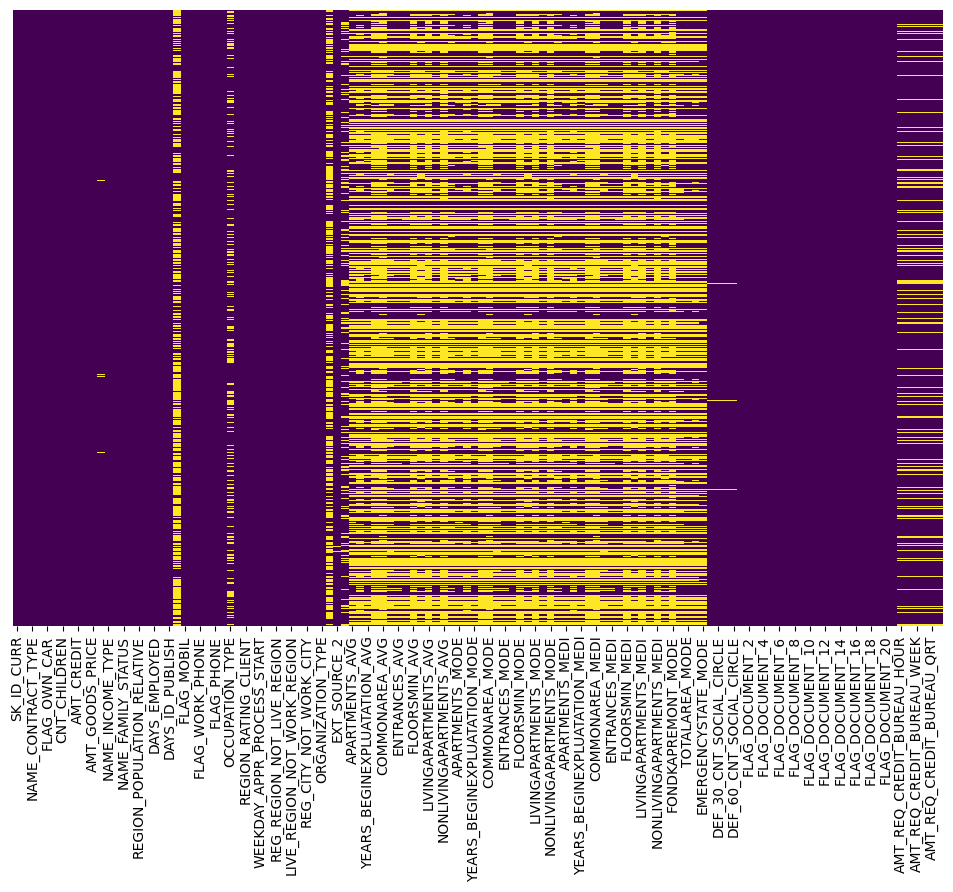

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

#### Parte A - Análise Exploratória e Diagnóstico (EDA)


Bom, o primeiro passso é identificar quais colunas dentre as 122 não serão importantes para o modelo de AM para realizar a Analise de Crédito. Geralmente, se destacam como os IDs, como SK_ID_CURR que não possui relevância, colunas de documentos, colunas com variáveis reduntantes, como por exemplo APARTMENTS possui AVG, MODE e MEDI., entre outras. As váriaveis úteis são aquelas contribuem para o modelo, como a de dados financeiros, perfil do usuário, dados de score, de moradia, profissão e histórico de créditos. Pensando nisso, a primeira análise foi com base no nome das colunas, deste modo, reduzi a quantidade total para as colunas de interesse ao modelo.

In [9]:
# Pega colunas específicas
columns = ['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
           'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
          'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']
df = data[columns]
df.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,2.0,2.0,2.0,2.0,-1134.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,1.0,0.0,1.0,0.0,-828.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,0.0,-815.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,2.0,0.0,2.0,0.0,-617.0,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,0.0,-1106.0,0.0,0.0,0.0,0.0,0.0


Colunas com geralmente mais de 70% de dados faltantes não são interessantes ao modelo de AM. A quantidade total foi reduzida para 37 colunas, agora será analisado a quantidade de itens faltantes.

<Axes: >

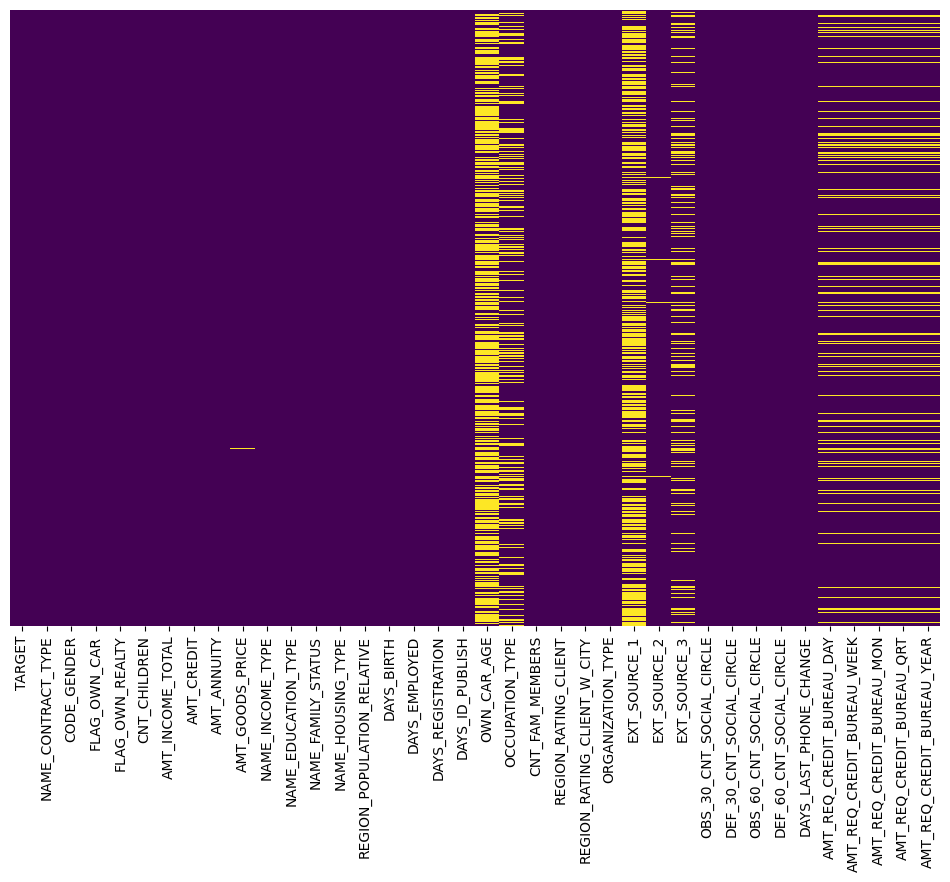

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [11]:
print("Porcentagem e valores null ou NA no dataframe")
((df.isnull() | df.isna()).sum() * 100 / df.index.size).round(2)

Porcentagem e valores null ou NA no dataframe


,0
TARGET,0.00
NAME_CONTRACT_TYPE,0.00
CODE_GENDER,0.00
FLAG_OWN_CAR,0.00
FLAG_OWN_REALTY,0.00
CNT_CHILDREN,0.00
AMT_INCOME_TOTAL,0.00
AMT_CREDIT,0.00
AMT_ANNUITY,0.00
AMT_GOODS_PRICE,0.09


Com as colunas selecionadas, é possível perceber que as colunas que mais possuem itens faltantes são OWN_CAR_AGE com 66% e EXT_SOURCE_1 com 56%. Variáveis com baixa proporção de dados faltantes, menores que 1% foram consideradas aproximadamente MCAR, ou seja, não tem relação com outras variáveis.

In [12]:
pd.crosstab(df['OWN_CAR_AGE'].isnull(), df['FLAG_OWN_CAR'])

FLAG_OWN_CAR,N,Y
OWN_CAR_AGE,,
False,0,104582
True,202924,5


Os missing na coluna OWN_CAR_AGE está diretamente relacionada à variável FLAG_OWN_CAR, caracterizando um mecanismo MAR.

In [13]:
df.groupby(df['EXT_SOURCE_1'].isnull())['AMT_INCOME_TOTAL'].mean()
df.groupby(df['EXT_SOURCE_1'].isnull())['TARGET'].mean()


,TARGET
EXT_SOURCE_1,
False,0.074955
True,0.085195


In [14]:
df.groupby(df['EXT_SOURCE_1'].isnull())['AMT_INCOME_TOTAL'].mean()

,AMT_INCOME_TOTAL
EXT_SOURCE_1,
False,176903.871659
True,162526.790848


Ao analisar a coluna EXT_SOURCE_1, verifica-se que indivíduos com dados faltantes apresentam taxa de inadimplência de aproximadamente 8,5%, enquanto aqueles com valores disponíveis apresentam cerca de 7,5%. Essa diferença sugere que a ausência de dados não ocorre de forma completamente aleatória, indicando missing do tipo MAR, em que os dados faltantes dependem de outras variáveis observadas.

In [15]:
df.groupby(df['OCCUPATION_TYPE'].isnull())['AMT_INCOME_TOTAL'].mean()
df.groupby(df['OCCUPATION_TYPE'].isnull())['TARGET'].mean()

,TARGET
OCCUPATION_TYPE,
False,0.087851
True,0.065131


Ao analisar a coluna OCCUPATION_TYPE, ela apresentou comportamento distinto em relação ao target quando analisada a presença de valores faltantes. Onde  indivíduos com informação de ocupação disponível apresentam maior taxa de inadimplência 8,7% em comparação àqueles com dados ausentes 6,5%. Isso indica que a ausência de dados não ocorre de forma aleatória, mas sim associada a características específicas dos indivíduos, caracterizando os dados faltantes como MAR.

In [16]:
df.groupby(df['EXT_SOURCE_3'].isnull())['AMT_INCOME_TOTAL'].mean()
df.groupby(df['EXT_SOURCE_3'].isnull())['TARGET'].mean()

,TARGET
EXT_SOURCE_3,
False,0.077665
True,0.093119


Para a coluna EXT_SOURCE_3, apresenta o mesmo comportamento da analise anterior, com a taxa de inadimplencia de 9,3% e os dados ausentes com 7,7%, se caracterizando como MAR também.

In [17]:
df.groupby(df['AMT_REQ_CREDIT_BUREAU_YEAR'].isnull())['TARGET'].mean()

,TARGET
AMT_REQ_CREDIT_BUREAU_YEAR,
False,0.077194
True,0.103374


Já na coluna AMT_REQ_CREDIT_BUREAU_YEAR, sua ausência pode estar associada à inexistência de histórico de crédito, com a taxa de inadimplencia de 10,3% e os dados ausentes com 7,7%, sugerindo MAR. Mas pode existir suspeita de MNAR, ou seja, o dado faltante depende do próprio valor que está faltando.

In [18]:
df.describe()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,...,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,...,1.422245,0.143421,1.405292,0.100049,-962.858788,0.007000,0.034362,0.267395,0.265474,1.899974
std,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886321,...,2.400989,0.446698,2.379803,0.362291,826.808487,0.110757,0.204685,0.916002,0.794056,1.869295
min,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,...,0.000000,0.000000,0.000000,0.000000,-4292.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,-7479.500000,...,0.000000,0.000000,0.000000,0.000000,-1570.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,-4504.000000,...,0.000000,0.000000,0.000000,0.000000,-757.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,-2010.000000,...,2.000000,0.000000,2.000000,0.000000,-274.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,0.000000,...,348.000000,34.000000,344.000000,24.000000,0.000000,9.000000,8.000000,27.000000,261.000000,25.000000


Analisando o dataset por inconsistências, através de df.drescribe() é possível identificar as inconsistências, como o MAX em CNT_CHILDREN, ou seja, a quantidade de filhos ser 19, um valor muito alto. Em DAYS_EMPLOYED com o MAX um número extremamente alto, que se dividir por 365 dias, equivale a aproximadamente 1000 anos, possivelmente um erro de codificação. Em AMT_INCOME_TOTAL, aqui vai um toque de atenção, pois o valor MAX foi um valor altissimo, o que pode ser real, sendo necessários analises complementares para verificar, mas para o modelo de AM, será um outlier fora do padrão, então precisa ser tratado. Outro outlier que pode ser encontrado é em AMT_REQ_CREDIT_BUREAU_QRT, com valor MAX de 261.

In [19]:
df['CNT_CHILDREN'].value_counts()

,count
CNT_CHILDREN,
0,215371
1,61119
2,26749
3,3717
4,429
5,84
6,21
7,7
14,3


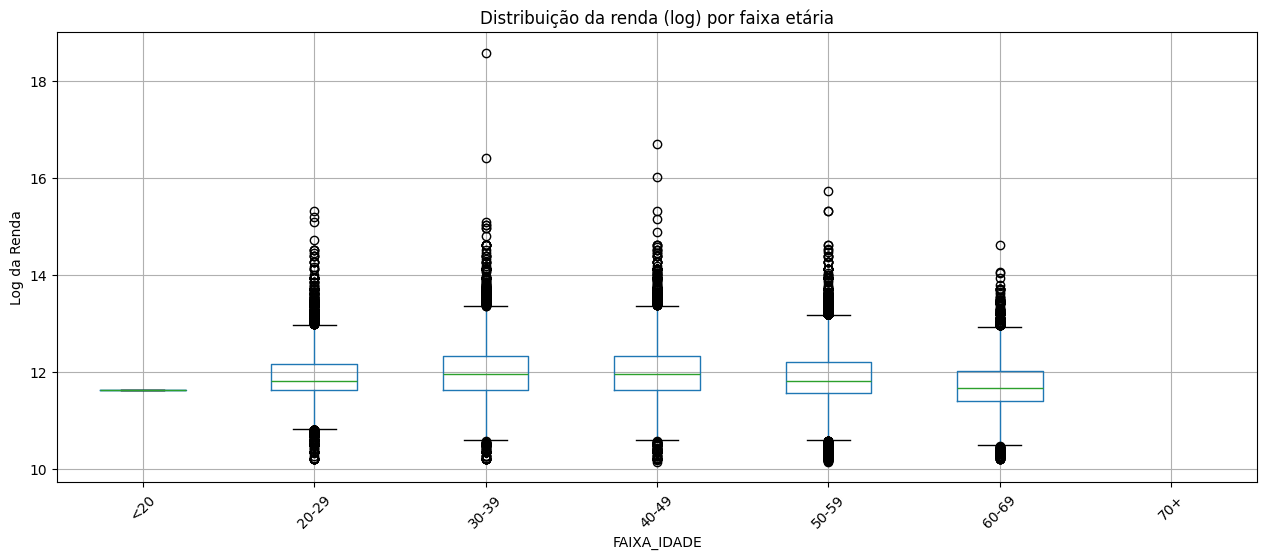

In [20]:
df['IDADE'] = (df['DAYS_BIRTH'] / -365).astype(int)

bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['FAIXA_IDADE'] = pd.cut(df['IDADE'], bins=bins, labels=labels, include_lowest=True)

df['LOG_RENDA'] = np.log1p(df['AMT_INCOME_TOTAL'])

ax = df.boxplot(column='LOG_RENDA', by='FAIXA_IDADE', figsize=(15,6))

ax.set_ylabel('Log da Renda')
plt.title('Distribuição da renda (log) por faixa etária')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

Ao analisar a faixa de renda por faixa etária, é possível notar a presença de outliers em todas as faixas etárias.

In [21]:
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

In [22]:
df['AMT_INCOME_TOTAL'] = np.log1p(df['AMT_INCOME_TOTAL'])

In [23]:
df['DAYS_EMPLOYED_MISS'] = df['DAYS_EMPLOYED'].isnull().astype(int)

In [24]:
df.describe()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,IDADE,LOG_RENDA,DAYS_EMPLOYED_MISS
count,307511.000000,307511.000000,307511.000000,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,252137.000000,307511.000000,...,306490.000000,307510.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,307511.000000,307511.000000,307511.000000
mean,0.080729,0.417052,11.909245,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,-2384.169325,-4986.120328,...,0.100049,-962.858788,0.007000,0.034362,0.267395,0.265474,1.899974,43.435968,11.909245,0.180072
std,0.272419,0.722121,0.488906,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,2338.360162,3522.886321,...,0.362291,826.808487,0.110757,0.204685,0.916002,0.794056,1.869295,11.954593,0.488906,0.384248
min,0.000000,0.000000,10.152338,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,-24672.000000,...,0.000000,-4292.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,10.152338,0.000000
25%,0.000000,0.000000,11.630717,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-3175.000000,-7479.500000,...,0.000000,-1570.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.000000,11.630717,0.000000
50%,0.000000,0.000000,11.899215,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1648.000000,-4504.000000,...,0.000000,-757.000000,0.000000,0.000000,0.000000,0.000000,1.000000,43.000000,11.899215,0.000000
75%,0.000000,1.000000,12.218500,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-767.000000,-2010.000000,...,0.000000,-274.000000,0.000000,0.000000,0.000000,0.000000,3.000000,53.000000,12.218500,0.000000
max,1.000000,19.000000,18.577685,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,0.000000,0.000000,...,24.000000,0.000000,9.000000,8.000000,27.000000,261.000000,25.000000,69.000000,18.577685,1.000000


Foram realizadas etapas de pré-processamento visando melhorar a qualidade dos dados. Inicialmente, valores inconsistentes na variável DAYS_EMPLOYED foram substituídos por valores ausentes (NaN). Em seguida, foi aplicada uma transformação logarítmica na variável AMT_INCOME_TOTAL, com o objetivo de reduzir a assimetria causada por outliers extremos. Por fim, foi criada uma variável indicadora de ausência (DAYS_EMPLOYED_MISS), permitindo capturar a possível informação contida no padrão de dados faltantes.

<Axes: >

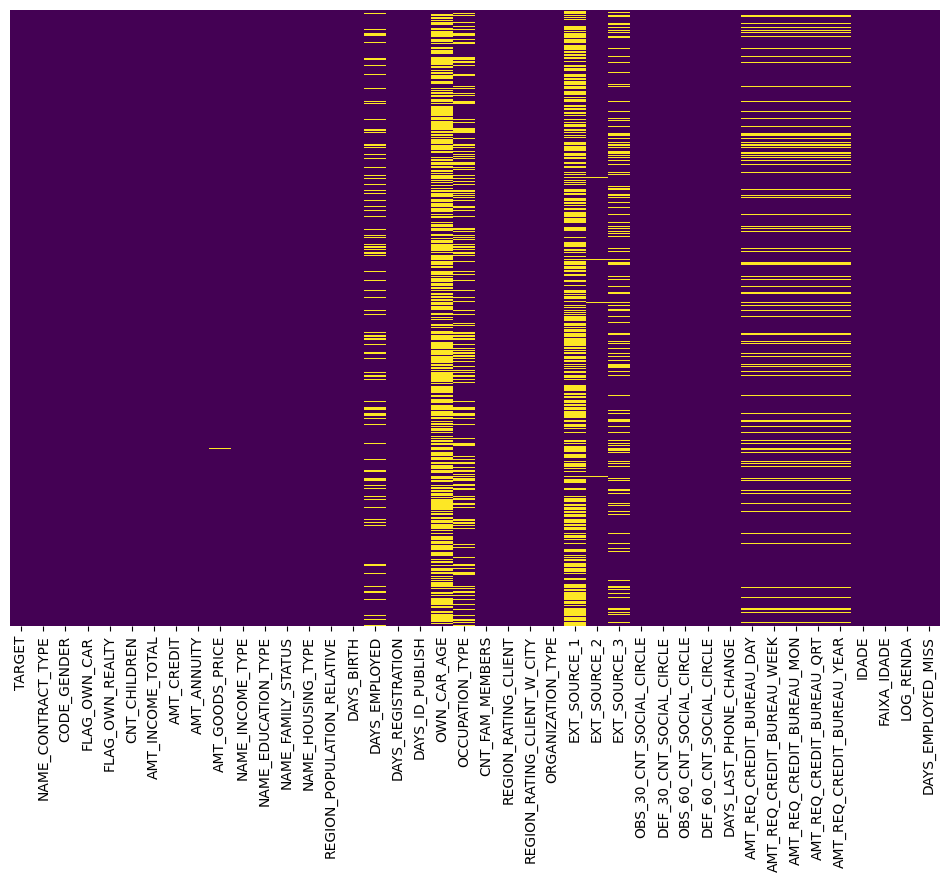

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

#### Parte B - Limpeza e Imputação Avançada

Para tratar os dados faltantes, se utiliza imputação condicional, onde os valores ausentes são estimados com base em grupos de individuos com caracteristicas semelhantes. Deste modo, a coluna AMT_INCOME_TOTAL foi imputada considerando o nível escolar, ou seja, NAME_EDUCATION_TYPE. Esses padrões de semelhança permite preservar relações estruturais dos dados, sendo mais adequaddo para o modelo.

In [26]:
df['AMT_INCOME_TOTAL'] = df.groupby('NAME_EDUCATION_TYPE')['AMT_INCOME_TOTAL']\
    .transform(lambda x: x.fillna(x.median()))

Além disso, foi imputado OCCUPATION_TYPE possui o tipo de dado categórigo, não sendo possível calcular a média, então, foi apenas imputado um valor "Unknow", pois muitos algoritmos de ML não aceitam valores nulos, assim invés de remover todo o objeto, apenas mantenho ela com a informação imputada.

In [27]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

Assim como na AMT_INCOME_TOTAL, foi imputado para os vazios da DAYS_EMPLOYED com a mediana específica de cada tipo de renda, ou seja, a mediana para os aposentados, mediada para os trabalhadores, entre outras.

In [28]:
df['DAYS_EMPLOYED'] = df.groupby('NAME_INCOME_TYPE')['DAYS_EMPLOYED']\
    .transform(lambda x: x.fillna(x.median()))

<Axes: >

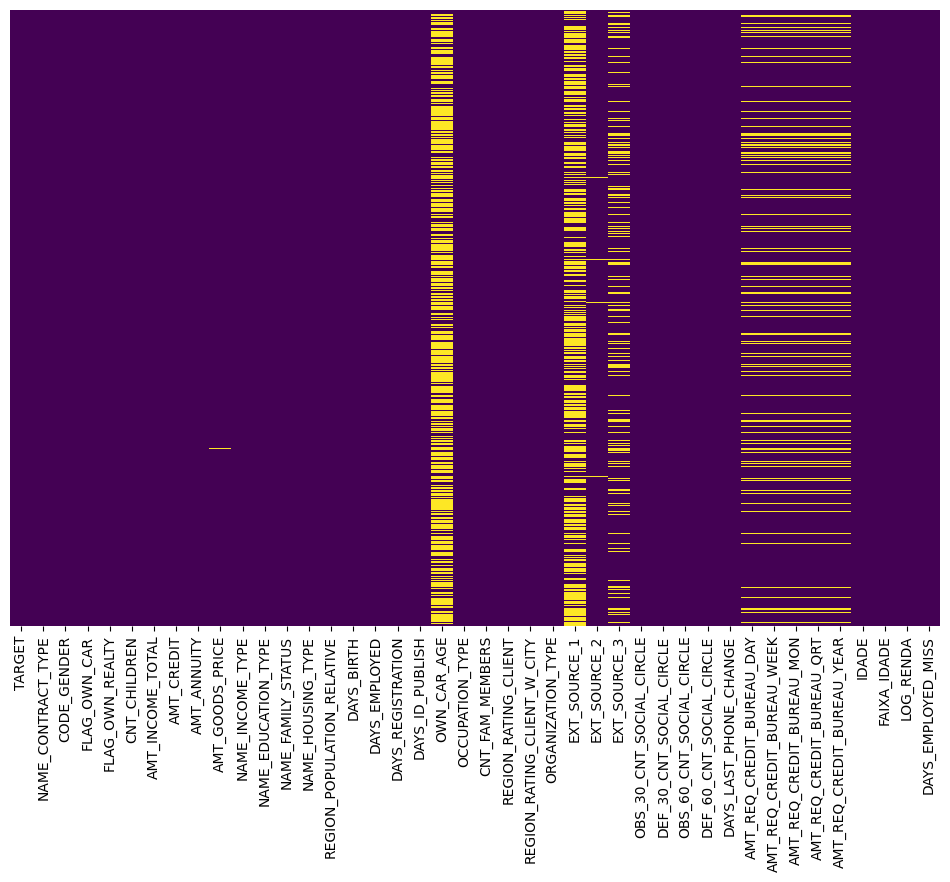

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

os itens faltantes da coluna OWN_CAR_AGE está diretamente associada à não posse de veículo. Assim, valores faltantes foram substituídos por zero, sendo criada uma variável indicadora para preservar a informação de ausência.

In [30]:
df['OWN_CAR_AGE_MISS'] = df['OWN_CAR_AGE'].isnull().astype(int)
df['OWN_CAR_AGE'] = df['OWN_CAR_AGE'].fillna(0)

Para AMT_REQ_CREDIT_BUREAU_YEAR, seja ela DAY, WEEK, MON ou QRT, o processo foi o mesmo, substituindo os valores por zero e armazenando em uma nova coluna, de forma que evite viés na imputação.

In [31]:
df['AMT_REQ_CREDIT_BUREAU_YEAR_MISS'] = df['AMT_REQ_CREDIT_BUREAU_YEAR'].isnull().astype(int)
df['AMT_REQ_CREDIT_BUREAU_YEAR'] = df['AMT_REQ_CREDIT_BUREAU_YEAR'].fillna(0)

In [32]:
df['AMT_REQ_CREDIT_BUREAU_DAY_MISS'] = df['AMT_REQ_CREDIT_BUREAU_DAY'].isnull().astype(int)
df['AMT_REQ_CREDIT_BUREAU_DAY'] = df['AMT_REQ_CREDIT_BUREAU_DAY'].fillna(0)

In [33]:
df['AMT_REQ_CREDIT_BUREAU_WEEK_MISS'] = df['AMT_REQ_CREDIT_BUREAU_WEEK'].isnull().astype(int)
df['AMT_REQ_CREDIT_BUREAU_WEEK'] = df['AMT_REQ_CREDIT_BUREAU_WEEK'].fillna(0)

In [34]:
df['AMT_REQ_CREDIT_BUREAU_MON_MISS'] = df['AMT_REQ_CREDIT_BUREAU_MON'].isnull().astype(int)
df['AMT_REQ_CREDIT_BUREAU_MON'] = df['AMT_REQ_CREDIT_BUREAU_MON'].fillna(0)

In [35]:
df['AMT_REQ_CREDIT_BUREAU_QRT_MISS'] = df['AMT_REQ_CREDIT_BUREAU_QRT'].isnull().astype(int)
df['AMT_REQ_CREDIT_BUREAU_QRT'] = df['AMT_REQ_CREDIT_BUREAU_QRT'].fillna(0)

Para EXT_SOURCE_1, 2 e 3, foi escolhido a imputação por regressão, por se tratar de colunas altamente correlacionadas entre si, deste modo, iremos usar outras colunas para prever os valores faltantes.

In [36]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

features_ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
imputer = IterativeImputer(max_iter=10,random_state=42)

df_imputed = imputer.fit_transform(df[features_ext])

In [37]:
df_imputed = pd.DataFrame(df_imputed, columns=features_ext)

df['EXT_SOURCE_1'] = df_imputed['EXT_SOURCE_1']
df['EXT_SOURCE_2'] = df_imputed['EXT_SOURCE_2']
df['EXT_SOURCE_3'] = df_imputed['EXT_SOURCE_3']

<Axes: >

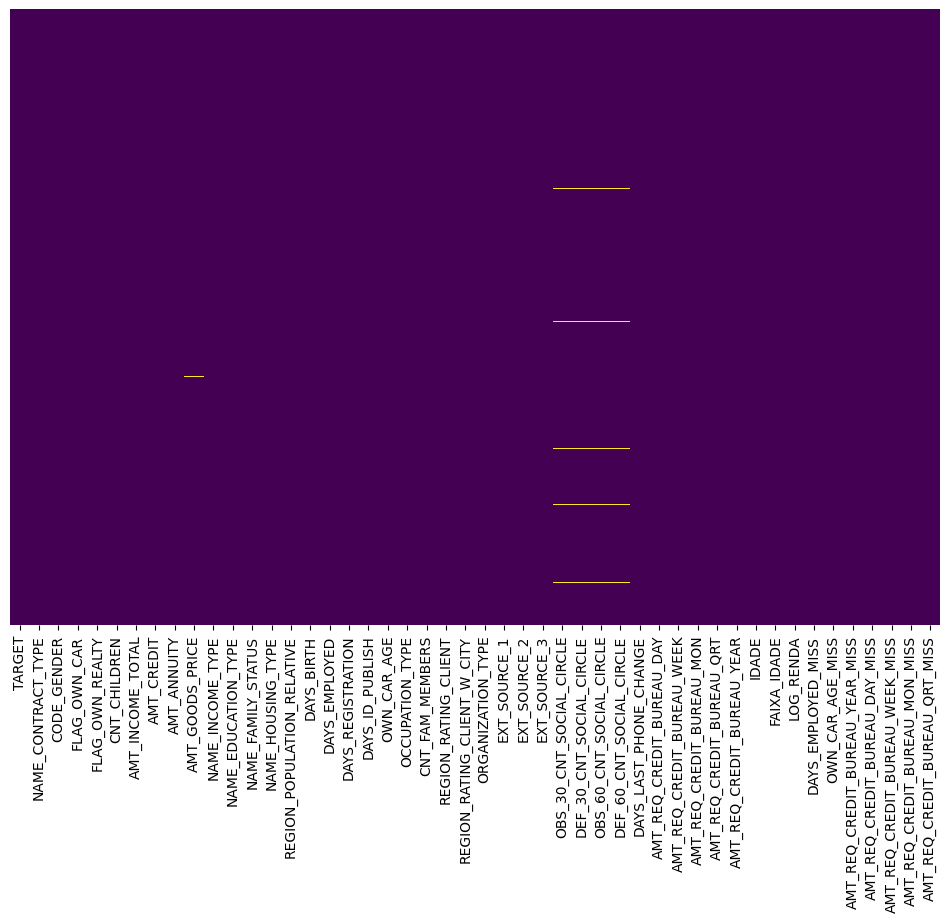

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

Para as colunas com baixa proporção de dados faltantes, como OBS_30_CNT_SOCIAL_CIRCLE, DEF_30_CNT_SOCIAL_CIRCLE, OBS_60_CNT_SOCIAL_CIRCLE, DEF_60_CNT_SOCIAL_CIRCLE, EXT_SOURCE_2 e AMT_GOODS_PRICE, foi adotada imputação simples utilizando a mediana, uma vez que o impacto dos valores ausentes é pequeno.

In [39]:
df['OBS_30_CNT_SOCIAL_CIRCLE'] = df['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_30_CNT_SOCIAL_CIRCLE'].median())

In [40]:
df['DEF_30_CNT_SOCIAL_CIRCLE'] = df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(df['DEF_30_CNT_SOCIAL_CIRCLE'].median())

In [41]:
df['OBS_60_CNT_SOCIAL_CIRCLE'] = df['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(df['OBS_60_CNT_SOCIAL_CIRCLE'].median())

In [42]:
df['DEF_60_CNT_SOCIAL_CIRCLE'] = df['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(df['DEF_60_CNT_SOCIAL_CIRCLE'].median())

In [43]:
df['AMT_GOODS_PRICE'] = df['AMT_GOODS_PRICE'].fillna(df['AMT_GOODS_PRICE'].median())

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 48 columns):
 #   Column                           Non-Null Count   Dtype   
---  ------                           --------------   -----   
 0   TARGET                           307511 non-null  int64   
 1   NAME_CONTRACT_TYPE               307511 non-null  object  
 2   CODE_GENDER                      307511 non-null  object  
 3   FLAG_OWN_CAR                     307511 non-null  object  
 4   FLAG_OWN_REALTY                  307511 non-null  object  
 5   CNT_CHILDREN                     307511 non-null  int64   
 6   AMT_INCOME_TOTAL                 307511 non-null  float64 
 7   AMT_CREDIT                       307511 non-null  float64 
 8   AMT_ANNUITY                      307499 non-null  float64 
 9   AMT_GOODS_PRICE                  307511 non-null  float64 
 10  NAME_INCOME_TYPE                 307511 non-null  object  
 11  NAME_EDUCATION_TYPE              307511 non-null  ob

In [45]:
df['AMT_ANNUITY'] = df['AMT_ANNUITY'].fillna(df['AMT_ANNUITY'].median())

In [46]:
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(df['DAYS_EMPLOYED'].median())

In [47]:
df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].fillna(df['CNT_FAM_MEMBERS'].median())

In [48]:
df['DAYS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].fillna(df['DAYS_LAST_PHONE_CHANGE'].median())

Para colunas com dados faltantes abaixo de 1%, foi apenas aplicado a mediana. Por se tratar de baixa ausencia de dados, não prejudica o modelo

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 48 columns):
 #   Column                           Non-Null Count   Dtype   
---  ------                           --------------   -----   
 0   TARGET                           307511 non-null  int64   
 1   NAME_CONTRACT_TYPE               307511 non-null  object  
 2   CODE_GENDER                      307511 non-null  object  
 3   FLAG_OWN_CAR                     307511 non-null  object  
 4   FLAG_OWN_REALTY                  307511 non-null  object  
 5   CNT_CHILDREN                     307511 non-null  int64   
 6   AMT_INCOME_TOTAL                 307511 non-null  float64 
 7   AMT_CREDIT                       307511 non-null  float64 
 8   AMT_ANNUITY                      307511 non-null  float64 
 9   AMT_GOODS_PRICE                  307511 non-null  float64 
 10  NAME_INCOME_TYPE                 307511 non-null  object  
 11  NAME_EDUCATION_TYPE              307511 non-null  ob

#### Parte C - Feature Engineering

Criação de alguns indicadores financeiros

Relação entre divida e renda do cliente

In [51]:
df['DEBT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

Relação entre emprestimo e renda

In [52]:
df['ANNUITY_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

Relação entre crédito e valor do bem, do financiamento

In [53]:
df['CREDIT_TO_GOODS'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

Relação da renda e a quantidade de filhos, ou seja, renda familiar

In [54]:
df['INCOME_PER_CHILD'] = df['AMT_INCOME_TOTAL'] / (1 + df['CNT_CHILDREN'])

Relação entre tempo trabalhado e idade, ver quantos anos já trabalhou em toda a vida

In [55]:
df['EMPLOYED_TO_AGE'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

Buscando quais as colunas com valores categóricos

In [56]:
for col in df.select_dtypes(include=['object', 'category']):
    print(col, df[col].nunique())

NAME_CONTRACT_TYPE 2
CODE_GENDER 3
FLAG_OWN_CAR 2
FLAG_OWN_REALTY 2
NAME_INCOME_TYPE 8
NAME_EDUCATION_TYPE 5
NAME_FAMILY_STATUS 6
NAME_HOUSING_TYPE 6
OCCUPATION_TYPE 19
ORGANIZATION_TYPE 58
FAIXA_IDADE 6


O One-Hot Encoding não foi aplicado a todas as colunas categóricas devido ao risco de explosão dimensional da alta cardinalidade. Nesses casos, optou-se por Target Encoding, que preserva a informação de forma mais compacta.

In [57]:
ohe_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'FAIXA_IDADE']

In [58]:
target_cols = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE']

As colunas OCCUPATION_TYPE, ORGANIZATION_TYPE e NAME_INCOME_TYPE , não foram submetida a One-Hot Encoding devido ao risco de explosão dimensional, sendo tratada com Target Encoding para preservar eficiência e capacidade preditiva.

In [59]:
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

In [60]:
for col in target_cols:
    mean_target = df.groupby(col)['TARGET'].mean()
    df[col + '_ENC'] = df[col].map(mean_target)

df.drop(columns=target_cols, inplace=True)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 70 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   TARGET                                             307511 non-null  int64  
 1   CNT_CHILDREN                                       307511 non-null  int64  
 2   AMT_INCOME_TOTAL                                   307511 non-null  float64
 3   AMT_CREDIT                                         307511 non-null  float64
 4   AMT_ANNUITY                                        307511 non-null  float64
 5   AMT_GOODS_PRICE                                    307511 non-null  float64
 6   REGION_POPULATION_RELATIVE                         307511 non-null  float64
 7   DAYS_BIRTH                                         307511 non-null  int64  
 8   DAYS_EMPLOYED                                      307511 non-null  float6

Alguns modelos podem dar inconsistências com dados do tipo booleano, desta forma, eles foram convertidos para inteiros.

In [62]:
df = df.astype({col: 'int8' for col in df.select_dtypes('bool').columns})

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 70 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   TARGET                                             307511 non-null  int64  
 1   CNT_CHILDREN                                       307511 non-null  int64  
 2   AMT_INCOME_TOTAL                                   307511 non-null  float64
 3   AMT_CREDIT                                         307511 non-null  float64
 4   AMT_ANNUITY                                        307511 non-null  float64
 5   AMT_GOODS_PRICE                                    307511 non-null  float64
 6   REGION_POPULATION_RELATIVE                         307511 non-null  float64
 7   DAYS_BIRTH                                         307511 non-null  int64  
 8   DAYS_EMPLOYED                                      307511 non-null  float6

Análise dos efeitos das transformações

In [87]:
df[['AMT_INCOME_TOTAL', 'LOG_RENDA']].skew()

,0
AMT_INCOME_TOTAL,0.169982
LOG_RENDA,0.169982


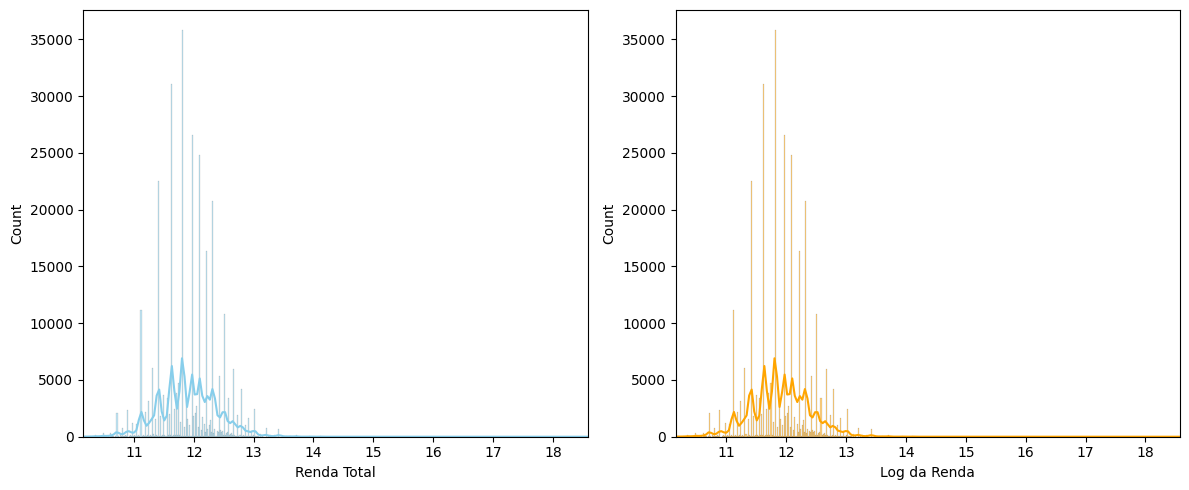

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['AMT_INCOME_TOTAL'], ax=axes[0], color='skyblue', kde=True)
axes[0].set_xlim(df['AMT_INCOME_TOTAL'].min(), df['AMT_INCOME_TOTAL'].max())
axes[0].set_xlabel('Renda Total')

sns.histplot(df['LOG_RENDA'], ax=axes[1], color='orange', kde=True)
axes[1].set_xlim(df['LOG_RENDA'].min(), df['LOG_RENDA'].max())
axes[1].set_xlabel('Log da Renda')
plt.tight_layout()
plt.show()

In [93]:
df.drop(columns=['LOG_RENDA'], inplace=True)

A transformação logarítmica foi testada, porém não apresentou impacto relevante na distribuição da coluna, sendo uma transformação sem aplicação, podendo ser removida do modelo.

In [90]:
df['AMT_CREDIT_LOG'] = np.log1p(df['AMT_CREDIT'])
df[['AMT_CREDIT', 'AMT_CREDIT_LOG']].skew()

,0
AMT_CREDIT,1.234778
AMT_CREDIT_LOG,-0.338818


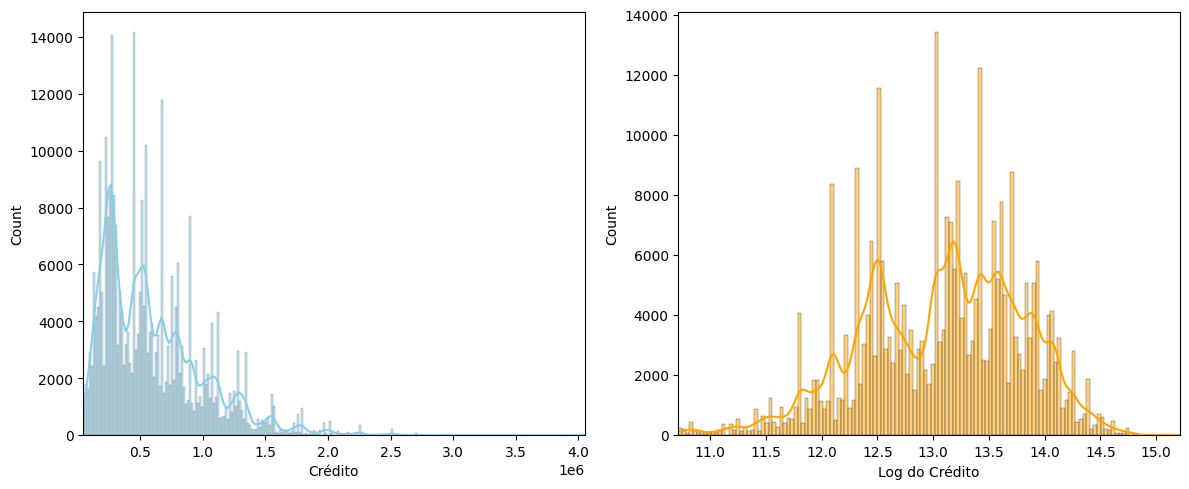

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['AMT_CREDIT'], ax=axes[0], color='skyblue', kde=True)
axes[0].set_xlim(df['AMT_CREDIT'].min(), df['AMT_CREDIT'].max())
axes[0].set_xlabel('Crédito')

sns.histplot(df['AMT_CREDIT_LOG'], ax=axes[1], color='orange', kde=True)
axes[1].set_xlim(df['AMT_CREDIT_LOG'].min(), df['AMT_CREDIT_LOG'].max())
axes[1].set_xlabel('Log do Crédito')
plt.tight_layout()
plt.show()

In [95]:
df['DEBT_TO_INCOME_LOG'] = np.log1p(df['DEBT_TO_INCOME'])
df[['DEBT_TO_INCOME', 'DEBT_TO_INCOME_LOG']].skew()

,0
DEBT_TO_INCOME,1.152068
DEBT_TO_INCOME_LOG,-0.348370


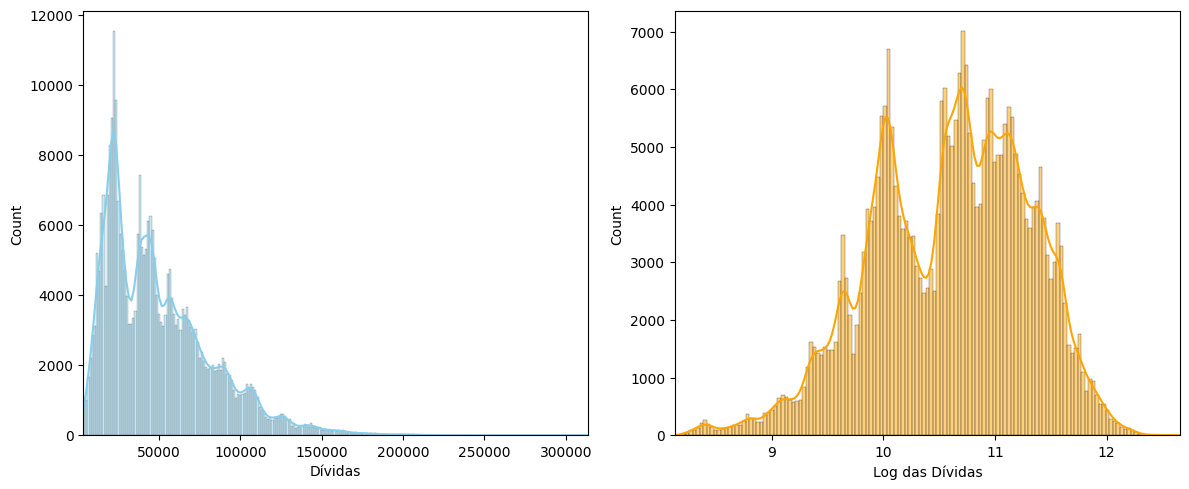

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['DEBT_TO_INCOME'], ax=axes[0], color='skyblue', kde=True)
axes[0].set_xlim(df['DEBT_TO_INCOME'].min(), df['DEBT_TO_INCOME'].max())
axes[0].set_xlabel('Dívidas')

sns.histplot(df['DEBT_TO_INCOME_LOG'], ax=axes[1], color='orange', kde=True)
axes[1].set_xlim(df['DEBT_TO_INCOME_LOG'].min(), df['DEBT_TO_INCOME_LOG'].max())
axes[1].set_xlabel('Log das Dívidas')
plt.tight_layout()
plt.show()

A coluna DEBT_TO_INCOME apresentava alta assimetria positiva, indicando a presença de valores extremos. Após a aplicação da transformação logarítmica, a assimetria foi significativamente reduzida, resultando em uma distribuição mais equilibrada e adequada para modelagem.

In [97]:
df['ANNUITY_TO_INCOME_LOG'] = np.log1p(df['ANNUITY_TO_INCOME'])
df[['ANNUITY_TO_INCOME', 'ANNUITY_TO_INCOME_LOG']].skew()

,0
ANNUITY_TO_INCOME,1.392472
ANNUITY_TO_INCOME_LOG,-0.377083


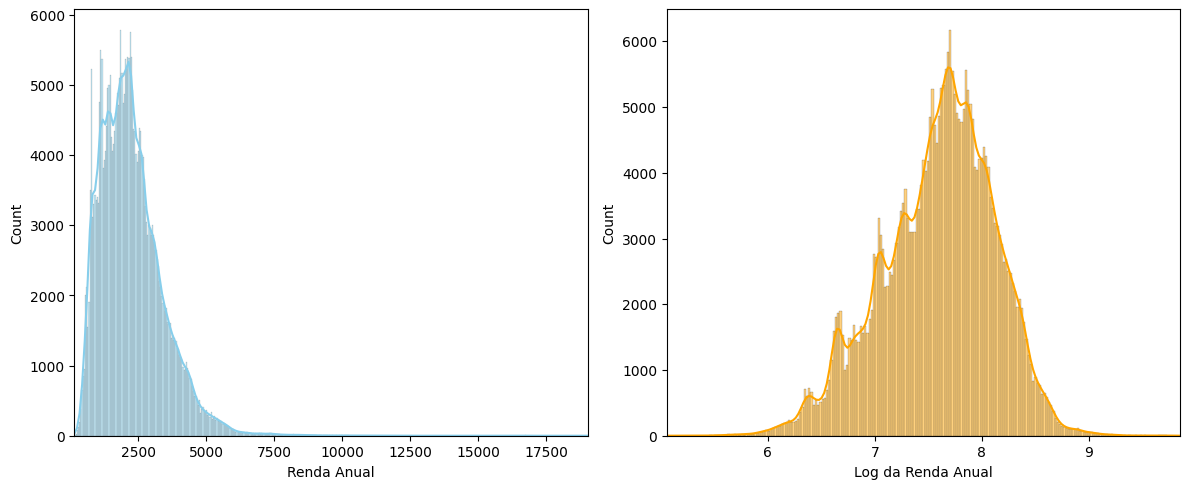

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['ANNUITY_TO_INCOME'], ax=axes[0], color='skyblue', kde=True)
axes[0].set_xlim(df['ANNUITY_TO_INCOME'].min(), df['ANNUITY_TO_INCOME'].max())
axes[0].set_xlabel('Emprestimo/Renda')

sns.histplot(df['ANNUITY_TO_INCOME_LOG'], ax=axes[1], color='orange', kde=True)
axes[1].set_xlim(df['ANNUITY_TO_INCOME_LOG'].min(), df['ANNUITY_TO_INCOME_LOG'].max())
axes[1].set_xlabel('Log de Emprestimo/Renda')
plt.tight_layout()
plt.show()

As colunas AMT_CREDIT, DEBT_TO_INCOME e ANNUITY_TO_INCOME apresentavam alta assimetria à direita, sendo aplicada transformação logarítmica para reduzir a influência de valores extremos e melhorar a distribuição dos dados.

In [101]:
df['CREDIT_TO_GOODS_LOG'] = np.log1p(df['CREDIT_TO_GOODS'])
df[['CREDIT_TO_GOODS', 'CREDIT_TO_GOODS_LOG']].skew()

,0
CREDIT_TO_GOODS,1.439811
CREDIT_TO_GOODS_LOG,0.548624


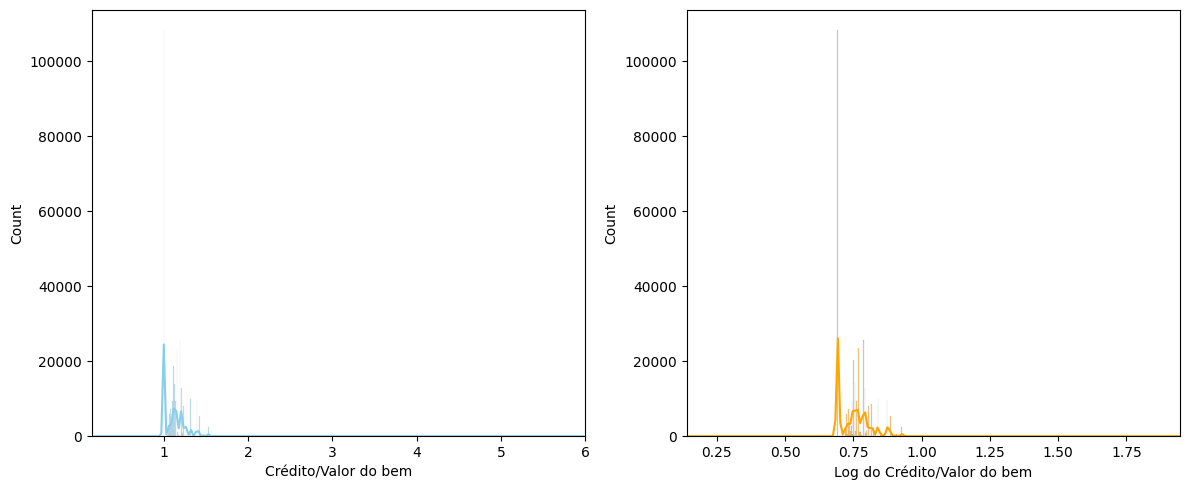

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['CREDIT_TO_GOODS'], ax=axes[0], color='skyblue', kde=True)
axes[0].set_xlim(df['CREDIT_TO_GOODS'].min(), df['CREDIT_TO_GOODS'].max())
axes[0].set_xlabel('Crédito/Valor do bem')

sns.histplot(df['CREDIT_TO_GOODS_LOG'], ax=axes[1], color='orange', kde=True)
axes[1].set_xlim(df['CREDIT_TO_GOODS_LOG'].min(), df['CREDIT_TO_GOODS_LOG'].max())
axes[1].set_xlabel('Log do Crédito/Valor do bem')
plt.tight_layout()
plt.show()

A coluna CREDIT_TO_GOODS apresentou alta assimetria positiva, sendo aplicada transformação logarítmica. A transformação reduziu significativamente a assimetria, tornando a distribuição mais equilibrada.

In [104]:
df['EMPLOYED_TO_AGE_LOG'] = np.log1p(df['EMPLOYED_TO_AGE'])
df[['EMPLOYED_TO_AGE', 'EMPLOYED_TO_AGE_LOG']].skew()

,0
EMPLOYED_TO_AGE,1.582793
EMPLOYED_TO_AGE_LOG,1.275267


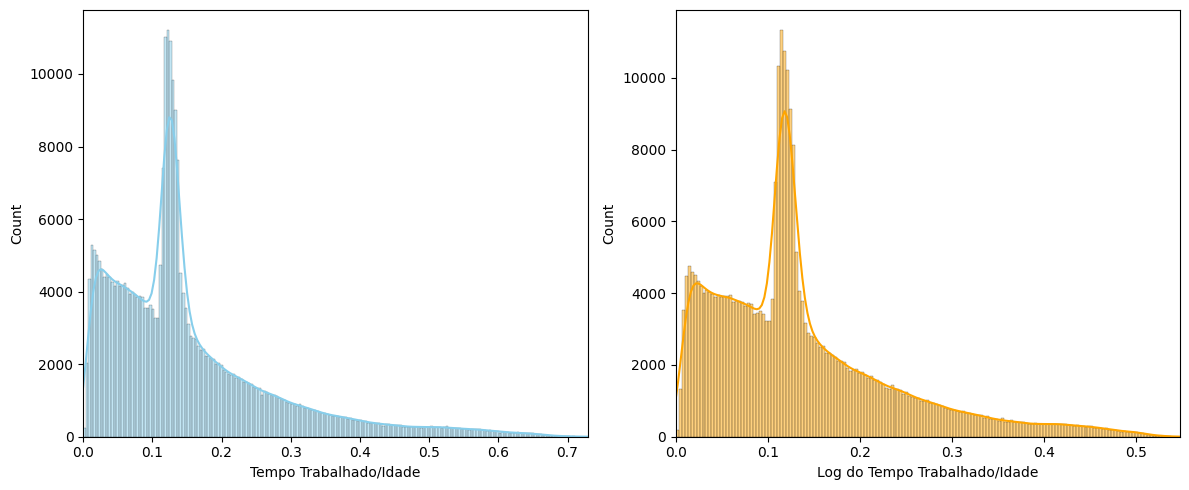

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['EMPLOYED_TO_AGE'], ax=axes[0], color='skyblue', kde=True)
axes[0].set_xlim(df['EMPLOYED_TO_AGE'].min(), df['EMPLOYED_TO_AGE'].max())
axes[0].set_xlabel('Tempo Trabalhado/Idade')

sns.histplot(df['EMPLOYED_TO_AGE_LOG'], ax=axes[1], color='orange', kde=True)
axes[1].set_xlim(df['EMPLOYED_TO_AGE_LOG'].min(), df['EMPLOYED_TO_AGE_LOG'].max())
axes[1].set_xlabel('Log do Tempo Trabalhado/Idade')
plt.tight_layout()
plt.show()

In [106]:
df.drop(columns=['EMPLOYED_TO_AGE_LOG'], inplace=True)

A coluna EMPLOYED_TO_AGE apresentou alta assimetria, e a transformação logarítmica não foi suficiente para corrigir sua distribuição. Isso indica que a coluna possui características estruturais que limitam a eficácia dessa transformação. Deste modo, posso manter a coluna original.

In [66]:
df.skew().sort_values(ascending=False).head(10)

,0
NAME_FAMILY_STATUS_Unknown,392.114779
CODE_GENDER_XNA,277.264314
AMT_REQ_CREDIT_BUREAU_QRT,141.400915
AMT_REQ_CREDIT_BUREAU_DAY,29.081577
OBS_30_CNT_SOCIAL_CIRCLE,12.143796
OBS_60_CNT_SOCIAL_CIRCLE,12.075153
NAME_HOUSING_TYPE_Office apartment,10.701162
AMT_REQ_CREDIT_BUREAU_WEEK,10.008033
NAME_EDUCATION_TYPE_Lower secondary,8.808971
AMT_REQ_CREDIT_BUREAU_MON,8.371505


In [107]:
cols = ['AMT_REQ_CREDIT_BUREAU_QRT','AMT_REQ_CREDIT_BUREAU_DAY', 'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON']

for col in cols:
    df[col + '_LOG'] = np.log1p(df[col])

Algumas colunas apresentaram valores elevados de assimetria devido à sua natureza binária, o que não representa um problema estatístico. Já variáveis de contagem, como requisições de crédito, apresentaram alta assimetria devido à predominância de valores zero, aplicando-se o log nessas transformações.

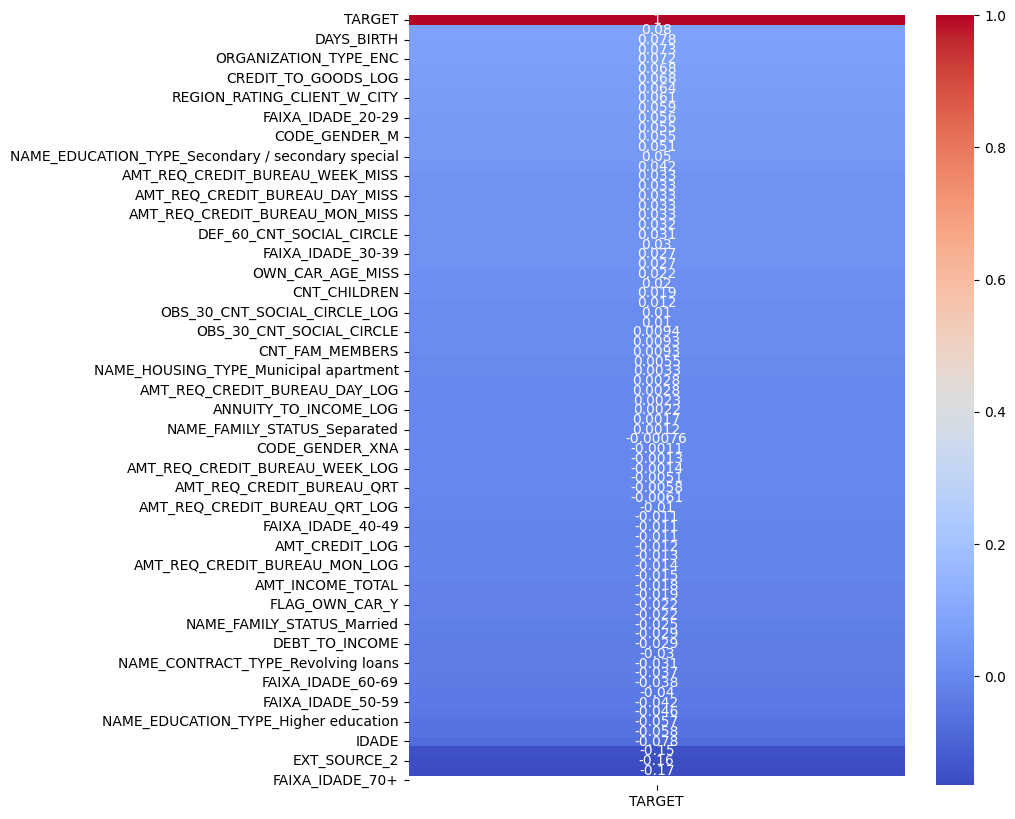

In [108]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,10))
sns.heatmap(corr[['TARGET']].sort_values(by='TARGET', ascending=False), annot=True, cmap='coolwarm')
plt.show()

## Discussão dos Resultados

Inicialmente, foi realizada a etapa de pré-processamento dos dados, a qual consistiu na compreensão do problema, na exploração e seleção das variáveis relevantes para a modelagem, bem como na identificação de dados faltantes e na correção de valores inconsistentes, visando garantir a qualidade e a adequação do conjunto de dados ao modelo final.

A remoção de outliers pode introduzir viés ao alterar a distribuição original dos dados e eliminar observações potencialmente relevantes. No entanto, neste trabalho, a remoção priorizou a exclusão de valores inconsistentes ou claramente incorretos. Dessa forma, o impacto no viés foi minimizado, preservando a representatividade dos dados para modelagem.

A imputação foi realizada de forma condicional, o que contribuiu para uma menor distorção da variância das variáveis. Ainda assim, observou-se uma leve redução na dispersão, indicando que parte da variabilidade original foi equilibrada. A imputação por regressão foi escolhido apenas nas colunas que possuia alta correlação entre si, sendo necessário utilizar outras colunas para prever os valores faltantes.

Foi realizado a análise de distribuição das colunas, com foco na identificação de assimetrias. Algumas colunas, como exemplo, a coluna AMT_CREDIT apresentava elevada assimetria positiva, indicando a presença de valores extremos. A aplicação da transformação logarítmica nesse caso mostrou-se eficaz, reduzindo significativamente a assimetria e tornando a distribuição mais adequada para modelagem.

Por outro lado, a coluna AMT_INCOME_TOTAL, apresentou baixa assimetria desde o início, e a aplicação do logaritmo não resultou em mudanças relevantes. Esse resultado evidencia a importância de avaliar cada transformação, evitando a aplicação de técnicas que não agregam valor ao modelo.

As features criadas, como DEBT_TO_INCOME, ANNUITY_TO_INCOME e CREDIT_TO_GOODS, contribuíram para a captura de relações financeiras mais complexas, especialmente no que se refere à capacidade de pagamento dos indivíduos. Entre essas, destacou-se a variável CREDIT_TO_GOODS, cuja transformação logarítmica reduziu substancialmente sua assimetria. Em contrapartida, a variável EMPLOYED_TO_AGE manteve alta assimetria mesmo após transformação, indicando limitações estruturais que não foram resolvidas por técnicas simples, sendo removida do modelo.

A análise dos Skewness evidenciou que variáveis binárias oriundas do processo de One-Hot Encoding apresentaram valores elevados de assimetria. No entanto, esse comportamento é esperado, dado o desbalanceamento natural dessas variáveis, o que não representa um problema estatístico que necessite de tratamento adicional.

A análise de correlação indicou que nenhuma variável isolada apresenta forte relação com a variável alvo, sendo as correlações observadas relativamente baixas. As variáveis EXT_SOURCE apresentaram as maiores correlações negativas, indicando forte relevância na predição de inadimplência. Os resultados indicam que o problema exige modelagem multivariada, uma vez que a relação entre as variáveis e o target não é linear nem isolada.

Conclui-se que, o processo de pré-processamento resultou em um conjunto de dados mais consistente, com melhor distribuição estatística e maior capacidade informativa. Embora as correlações individuais sejam baixas, o conjunto das transformações realizadas tende a favorecer o desempenho de modelos preditivos mais robustos.